# Day 15 of ML 30-Days Challenge

# Task

**Random Forest Regression**: Learn the power of ensemble methods with Random Forests. Understand how bagging (bootstrap aggregating) and feature randomness combine to create multiple decorrelated decision trees, reducing variance and improving accuracy.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

###1. Create a dataset

In [34]:
rng = np.random.RandomState(42)
n_rows = 200

X1 = np.linspace(0, 10, n_rows)
X2 = rng.uniform(-3, 3, n_rows)
X3 = rng.normal(0, 1, n_rows)

y_true = ( 3*np.sin(X1) + 0.8*X2 - 0.5*(X3**2) + 0.3*X1*X2/10 )
noise = rng.normal(0, 0.7, n_rows)
y = y_true + noise

df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'y': y
})

X = df[['X1', 'X2', 'X3']].values
y = df['y'].values
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42 )

df.describe()

,X1,X2,X3,y
count,200.000000,200.000000,200.000000,200.000000
mean,5.000000,-0.095963,0.067414,-0.045421
std,2.908502,1.769349,0.969045,2.912051
min,0.000000,-2.966867,-3.241267,-9.018161
25%,2.500000,-1.628506,-0.665630,-1.870804
50%,5.000000,-0.033082,0.089435,0.037093
75%,7.500000,1.541158,0.666497,2.431916
max,10.000000,2.921322,3.852731,5.835749


###2. Decision Tree Regressor

In [35]:
dt = DecisionTreeRegressor(random_state=42, max_depth=None)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

###3. Random Forest Regressor

In [36]:
rf = RandomForestRegressor( n_estimators=300, max_depth=None, random_state=42, n_jobs=-1 )
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

###4. Metrics (Just caompare Decision Tree and Random Forest)

In [37]:
def metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    print(f'{name}: R^2={r2:.3f}  RMSE={rmse:.3f}')

print('Test set performance:')
metrics(y_test, y_pred_dt, 'Decision Tree')
metrics(y_test, y_pred_rf, 'Random Forest')

Test set performance:
Decision Tree: R^2=0.473  RMSE=3.442
Random Forest: R^2=0.850  RMSE=0.982


###5. Visualization

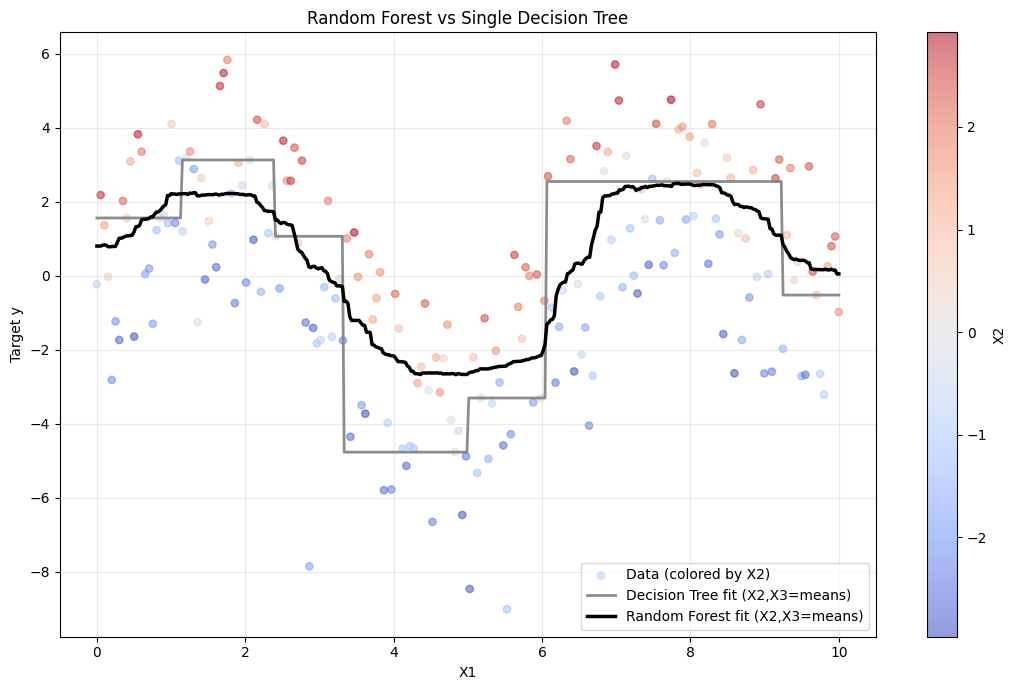

In [38]:
x1_grid = np.linspace(df['X1'].min(), df['X1'].max(), 400)
x2_mean = X_train[:,1].mean()
x3_mean = X_train[:,2].mean()
X_grid = np.column_stack([x1_grid, np.full_like(x1_grid, x2_mean), np.full_like(x1_grid, x3_mean)])

y_grid_dt = dt.predict(X_grid)
y_grid_rf = rf.predict(X_grid)

plt.figure(figsize=(11, 7))

sc = plt.scatter(df['X1'], df['y'], c=df['X2'], cmap='coolwarm', alpha=0.55, s=28, label='Data (colored by X2)')
cbar = plt.colorbar(sc)
cbar.set_label('X2')

plt.plot(x1_grid, y_grid_dt, color='gray', lw=2, alpha=0.9, label='Decision Tree fit (X2,X3=means)')
plt.plot(x1_grid, y_grid_rf, color='black', lw=2.5, label='Random Forest fit (X2,X3=means)')

plt.title('Random Forest vs Single Decision Tree')
plt.xlabel('X1')
plt.ylabel('Target y')
plt.legend(loc='best')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

####Feature Importances (Random Forest)

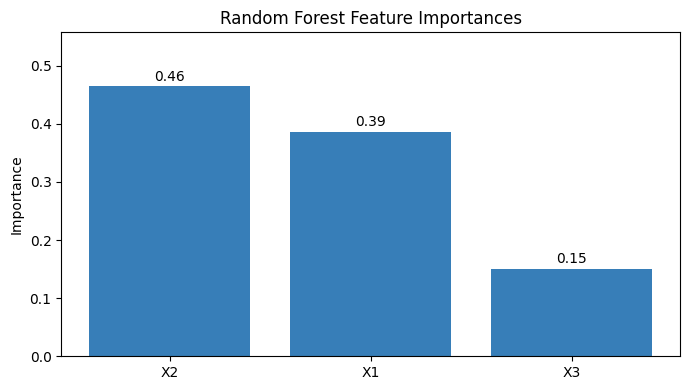

In [39]:
importances = rf.feature_importances_
feat_names = ['X1','X2','X3']
order = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar([feat_names[i] for i in order], importances[order], color='#377eb8')
plt.title('Random Forest Feature Importances')
plt.ylabel('Importance')
for i, v in enumerate(importances[order]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.ylim(0, max(importances)*1.2)
plt.tight_layout()
plt.show()

####plots to compare predictions vs truth

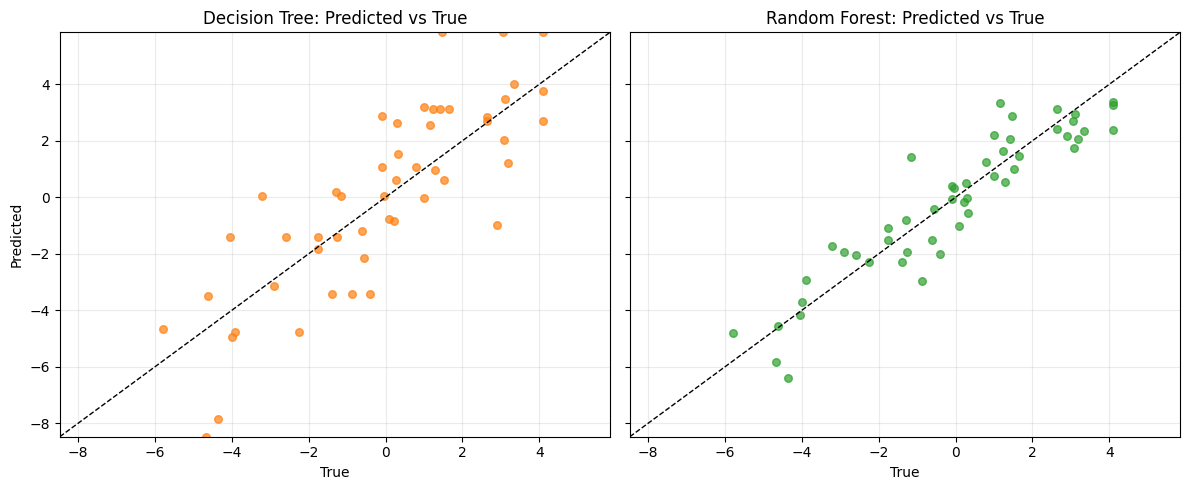

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)
lims = [min(y_test.min(), y_pred_dt.min(), y_pred_rf.min()),
        max(y_test.max(), y_pred_dt.max(), y_pred_rf.max())]

ax[0].scatter(y_test, y_pred_dt, s=30, alpha=0.7, color='tab:orange')
ax[0].plot(lims, lims, 'k--', lw=1)
ax[0].set_title('Decision Tree: Predicted vs True')
ax[0].set_xlabel('True')
ax[0].set_ylabel('Predicted')

ax[1].scatter(y_test, y_pred_rf, s=30, alpha=0.7, color='tab:green')
ax[1].plot(lims, lims, 'k--', lw=1)
ax[1].set_title('Random Forest: Predicted vs True')
ax[1].set_xlabel('True')

for a in ax:
    a.grid(alpha=0.25)
    a.set_xlim(lims)
    a.set_ylim(lims)

plt.tight_layout()
plt.show()